# **Information**

**Codes**

*Santiago Lamas Fresard*

## **Bibliography used**

1. Piazza, A. (2019). A discussion of vintage optimization models in Forest Economics. Forest Science, 66(4), 469–477. https://doi.org/10.1093/forsci/fxz056
2. Pukkala, T., Vauhkonen, J., Korhonen, K. T., & Packalen, T. (2021). Self-learning growth simulator for modelling forest stand dynamics in changing conditions. Forestry an International Journal of Forest Research, 94(3), 333–346. https://doi.org/10.1093/forestry/cpab008
3. Jenkins, J. C., Chojnacky, D. C., Heath, L. S., & Birdsey, R. A. (2003). National-Scale Biomass Estimators for United States Tree Species. Forest Science, 49(1), 12–35. https://doi.org/10.1093/forestscience/49.1.12

# **Inicialization**

Importing of useful libraries.

In [1]:
import Distributions
import Gurobi
import Ipopt
import JuMP
import LinearAlgebra
import Measures
import Plots
import Random
import Roots
import SDDP

using Distributions
using Gurobi
using Ipopt
using JuMP
using LinearAlgebra
using Measures
using Plots
gr()
using Printf
using Random
using Roots
using SDDP

const GRB_ENV = Gurobi.Env();

Set parameter Username
Set parameter LicenseID to value 2760931
Academic license - for non-commercial use only - expires 2027-01-05


In [2]:
# Parameters to use in the problem
α = 0.5 # risk aversion parameter for the utility function
UB = 500 # upper bound for the objective function

# Useful functions
obj = x -> x^(1-α)/(1-α) # objective function
deriv_obj = x -> x^-α # derivative of the objective function
inv_obj = y -> ((1-α)*y)^(1/(1-α)) # inverse of the objective function

# Parameters to estimate the objective function
T = inv_obj(UB)
ny = 200 # number of points for the discretization
dy = UB/ny # step sizes for the discretization

# Uniform discretization on the y-axis
d_unif_y = 1:dy:UB

# Preimage of the discretizations
f_inv_y = inv_obj.(d_unif_y) # uniform on y-axis

# Coefficients obtained
as = deriv_obj.(f_inv_y)              
bs = d_unif_y .- as .* f_inv_y;

## **Model testing**

We test the method previously defined on the Mitra & Wan's model.

In [3]:
UB = 5000 # upper bound for the objective function
b = 0.975 # discount factor used by Buongiorno
α = 0.5 # risk aversion parameter for the utility function
n = 5 # number of age classes
f = [0.8, 4.2, 16.99, 68.1, 84] # biomass coeffcients
x0 = [1.0, 0.0, 0.0, 0.0, 0.0] # initial state

# Cyclic graph consisting of one node with a probability of (1-b) of exiting the cycle 
graph = SDDP.UnicyclicGraph(b; num_nodes = 1)

# Number of training iterations for the models and number of simulations to compute the bounds
n_train_iterations = 50
n_simulations = 100;

# **Pukkala's model**

In [4]:
n_classes = 8 # number of diameter classes to study
range_classes = 5 # range of each class
avg_diams = [range_classes*(k-1/2) for k in 1:n_classes] # average diameters of each class
BAs = [pi*d^2/40000 for d in avg_diams] # basal area per tree of each class
X0 = [500, 0, 0, 0, 0, 0, 0, 0]; # initial condition

## **Fixed basal areas**

In [5]:
# Coefficients used for diameter increase
coefs_diam_pine = [-7.1552, 0.4415, -0.0685, -0.2027, -0.1236, 1.1198]
coefs_diam_spruce = [-12.7527, 0.1693, -0.0301, -0.1875, -0.0563, 1.9747]
coefs_diam_broadleaf = [-8.6306, 0.5097, -0.0829, -0.3864, -0.0545,  1.3163]

"""
     diam_fn(d:Float64, TS:Int64, coefs:Vector{Float64})-> Float64

Returns DI(d,TS) = exp(f(d,TS)), based on the coefficients.

# Arguments
- `d::Float64`: diameter of the tree the function DI is being applied to.
- `TS::Int64`: effective temperature sum the function DI is being applied to.
- `coefs::Vector{Float64}`: coefficients of the function f.
"""
diam_fn = (d, TS, coefs) -> exp(sum(coefs.*[1, sqrt(d), d, log(25+1), 10/sqrt(d+1), log(TS)]))

"""
     tr_diam(TS:Int64,fn:Function)-> Matrix{Float64}

Returns the transition matrix P, taking DI = fn.

# Arguments
- `TS::Int64`: effective temperature sum the function DI is being applied to.
- `fn:Function`: Diameter-increase function.
"""
function tr_diam(fn)
    tr = zeros(n_classes,n_classes)
    for i in 1:n_classes-1
        # The help function gives the increased diameter for each class, minus the maximum diamter 
        # of said class. Thus, its unique zero (TBP) is the diameter in the class that reaches exactly
        # that maximum diameter. In consequence, all diameters before it remain in the class.
        help = d -> d + fn(d) - range_classes*i
        crit = find_zero(help, range_classes*i)
        frac = (crit - range_classes*(i-1))/range_classes
        tr[i,i] = frac
        tr[i+1,i] = 1 - frac
    end
    # It's asummed that all trees on the larger class remain there.
    tr[end,end] = 1
    return tr
end

# Transition matrices for each species
diam = Dict()
diam["Pine"] = TS -> tr_diam(d -> diam_fn(d, TS, coefs_diam_pine))
diam["Spruce"] = TS -> tr_diam(d -> diam_fn(d, TS, coefs_diam_spruce))
diam["Birch"] = TS -> tr_diam(d -> diam_fn(d, TS, coefs_diam_broadleaf))
diam["Other broadleaf species"] = TS -> tr_diam(d -> diam_fn(d, TS, coefs_diam_broadleaf));

In [6]:
# Coefficients used for survival
coefs_survival_pine_mixed = [4.1505, 3.1513, -0.3575, -0.4001]
coefs_survival_spruce_mixed = [9.6649, 1.0157, -0.1577, -0.3244]
coefs_survival_broadleaf_mixed = [3.6655, 1.0650, -0.1509, -0.0326]
coefs_survival_pine_fixed = [1.41223, 1.8852, -0.21317, -0.25637]
coefs_survival_spruce_fixed = [5.01677, 0.36902, -0.07504, -0.2319]
coefs_survival_broadleaf_fixed = [1.60895, 0.71578, -0.08236, -0.13481]

"""
     surviv_fn(d:Float64, coefs:Vector{Float64})-> Float64

Returns S(d) = 1/(1+exp(-g(d)), based on the coefficients.

# Arguments
- `d::Float64`: diameter of the tree the function S is being applied to.
- `coefs::Vector{Float64}`: coefficients of the function g.
"""
surviv_fn = (d, coefs) -> 1/( 1+exp( -sum( coefs.*[1, sqrt(d), d, 10/sqrt(d+1)] ) ) )

"""
     survival_eval(coefs:Vector{Float64})-> Vector{Float64}

Returns the survival rates assigned to each class based on the coefficents.

# Arguments
- `coefs::Vector{Float64}`: coefficients of the function g.
"""
survival_eval = coefs -> [ surviv_fn(d, coefs) for d in avg_diams ]

# Survival rates for each species and each effects model.
surviv = Dict()
surviv["Pine", "fixed"] = survival_eval(coefs_survival_pine_fixed)
surviv["Spruce", "fixed"] = survival_eval(coefs_survival_spruce_fixed)
surviv["Birch", "fixed"] = survival_eval(coefs_survival_broadleaf_fixed)
surviv["Other broadleaf species", "fixed"] = survival_eval(coefs_survival_broadleaf_fixed)
surviv["Pine", "mixed"] = survival_eval(coefs_survival_pine_mixed)
surviv["Spruce", "mixed"] = survival_eval(coefs_survival_spruce_mixed)
surviv["Birch", "mixed"] = survival_eval(coefs_survival_broadleaf_mixed)
surviv["Other broadleaf species", "mixed"] = survival_eval(coefs_survival_broadleaf_mixed);

In [7]:
# Coefficients used for ingrowth
coefs_ingrowth_pine = [-6.6933, 1.9051, -0.5035]
coefs_ingrowth_spruce = [-9.6128, 2.2897, -0.8739]
coefs_ingrowth_birch = [-3.2919, 1.5438, -1.2920]
coefs_ingrowth_broadleaf = [-48.4331,  7.6107, -0.2227]

"""
     ingrowth_fn(d:Float64, TS::Int64, coefs:Vector{Float64})-> Float64

Returns NI(d,TS) = exp(h(d,TS)), based on the coefficients.

# Arguments
- `d::Float64`: diameter of the tree the function NI is being applied to.
- `TS::Int64`: effective temperature sum the function DI is being applied to.
- `coefs::Vector{Float64}`: coefficients of the function h.
"""
ingrowth_fn = (d, TS, coefs) -> exp(sum(coefs.*[1, log(TS), sqrt(25)]))

# Ingrowth functions for each species.
ingrowth = Dict()
ingrowth["Pine"] = (d,TS) -> ingrowth_fn(d, TS, coefs_ingrowth_pine)
ingrowth["Spruce"] = (d,TS) -> ingrowth_fn(d, TS, coefs_ingrowth_spruce)
ingrowth["Birch"] = (d,TS) -> ingrowth_fn(d, TS, coefs_ingrowth_birch)
ingrowth["Other broadleaf species"] = (d,TS) -> ingrowth_fn(d, TS, coefs_ingrowth_broadleaf);

In [56]:
TS_test = 1100;

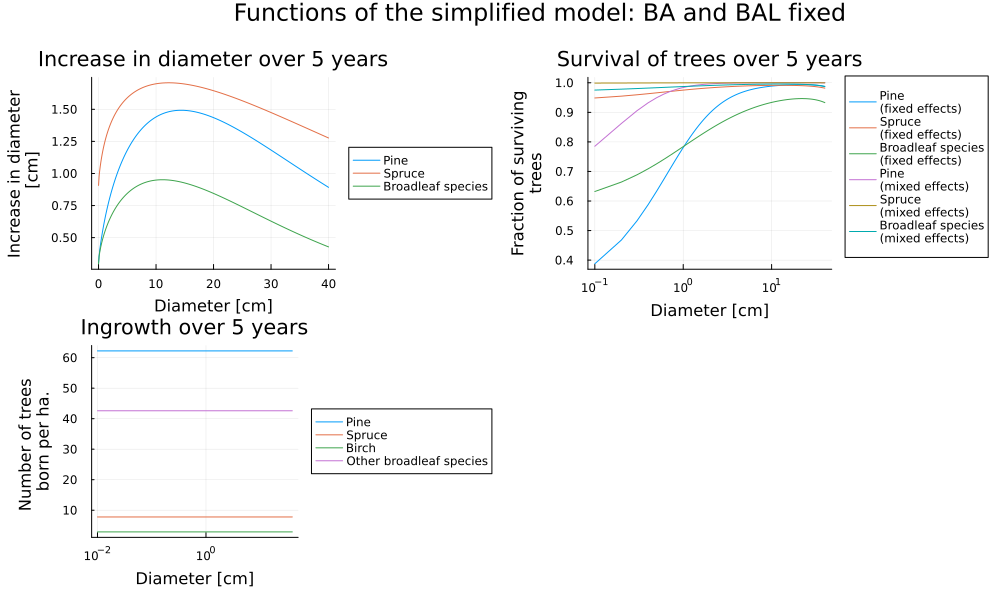

In [57]:
x1 = 0:0.1:n_classes*range_classes
p1 = plot(
    x1, 
    [d -> diam_fn(d, TS_test, coefs_diam_pine),
    d -> diam_fn(d, TS_test, coefs_diam_spruce),
    d -> diam_fn(d, TS_test, coefs_diam_broadleaf)], 
    xlabel="Diameter [cm]", 
    ylabel="Increase in diameter\n [cm]", 
    left_margin=5mm,
    title="Increase in diameter over 5 years", 
    label=["Pine" "Spruce" "Broadleaf species"], 
    legend=:outerright
    )

x2 = 0.1:0.1:n_classes*range_classes
p2 = plot(
    x2, 
    [d -> surviv_fn(d,coefs_survival_pine_fixed), 
    d -> surviv_fn(d, coefs_survival_spruce_fixed), 
    d -> surviv_fn(d, coefs_survival_broadleaf_fixed), 
    d -> surviv_fn(d, coefs_survival_pine_mixed), 
    d -> surviv_fn(d, coefs_survival_spruce_mixed), 
    d -> surviv_fn(d, coefs_survival_broadleaf_mixed)], 
    xaxis=:log10, 
    xlabel="Diameter [cm]", 
    ylabel="Fraction of surviving\ntrees",
    left_margin=5mm,
    title="Survival of trees over 5 years",
    label=["Pine\n(fixed effects)" "Spruce\n(fixed effects)" "Broadleaf species\n(fixed effects)" "Pine\n(mixed effects)" "Spruce\n(mixed effects)" "Broadleaf species\n(mixed effects)"],
    legend=:outerright
    )

x3 = 0.01:1:n_classes*range_classes
p3 = plot(
    x3, 
    [d->ingrowth["Pine"](d, TS_test), 
    d->ingrowth["Spruce"](d, TS_test), 
    d->ingrowth["Birch"](d, TS_test), 
    d->ingrowth["Other broadleaf species"](d, TS_test)],
    xaxis=:log10, 
    xlabel="Diameter [cm]", 
    ylabel="Number of trees \nborn per ha.",
    bottom_margin=5mm, 
    title="Ingrowth over 5 years", 
    label=["Pine" "Spruce" "Birch" "Other broadleaf species"], 
    legend=:outerright
    )
plot(
    p1, p2, p3, 
    layout=(2,2), 
    size=(1000,600), 
    plot_title="Functions of the simplified model: BA and BAL fixed", 
    plot_titlevspan=0.08
    )

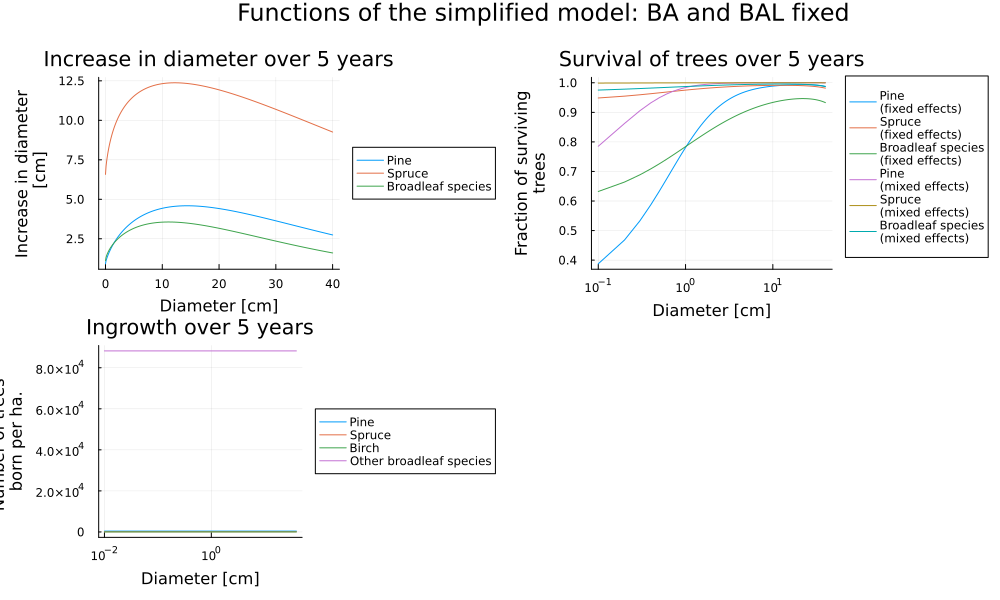

In [58]:
TS_test2 = 3000

x1 = 0:0.1:n_classes*range_classes
p1 = plot(
    x1, 
    [d -> diam_fn(d, TS_test2, coefs_diam_pine),
    d -> diam_fn(d, TS_test2, coefs_diam_spruce),
    d -> diam_fn(d, TS_test2, coefs_diam_broadleaf)], 
    xlabel="Diameter [cm]", 
    ylabel="Increase in diameter\n [cm]", 
    left_margin=5mm,
    title="Increase in diameter over 5 years", 
    label=["Pine" "Spruce" "Broadleaf species"], 
    legend=:outerright
    )

x2 = 0.1:0.1:n_classes*range_classes
p2 = plot(
    x2, 
    [d -> surviv_fn(d,coefs_survival_pine_fixed), 
    d -> surviv_fn(d, coefs_survival_spruce_fixed), 
    d -> surviv_fn(d, coefs_survival_broadleaf_fixed), 
    d -> surviv_fn(d, coefs_survival_pine_mixed), 
    d -> surviv_fn(d, coefs_survival_spruce_mixed), 
    d -> surviv_fn(d, coefs_survival_broadleaf_mixed)], 
    xaxis=:log10, 
    xlabel="Diameter [cm]", 
    ylabel="Fraction of surviving\ntrees",
    left_margin=5mm,
    title="Survival of trees over 5 years",
    label=["Pine\n(fixed effects)" "Spruce\n(fixed effects)" "Broadleaf species\n(fixed effects)" "Pine\n(mixed effects)" "Spruce\n(mixed effects)" "Broadleaf species\n(mixed effects)"],
    legend=:outerright
    )

x3 = 0.01:1:n_classes*range_classes
p3 = plot(
    x3, 
    [d->ingrowth["Pine"](d, TS_test2), 
    d->ingrowth["Spruce"](d, TS_test2), 
    d->ingrowth["Birch"](d, TS_test2), 
    d->ingrowth["Other broadleaf species"](d, TS_test2)],
    xaxis=:log10, 
    xlabel="Diameter [cm]", 
    ylabel="Number of trees \nborn per ha.",
    bottom_margin=5mm, 
    title="Ingrowth over 5 years", 
    label=["Pine" "Spruce" "Birch" "Other broadleaf species"], 
    legend=:outerright
    )
plot(
    p1, p2, p3, 
    layout=(2,2), 
    size=(1000,600), 
    plot_title="Functions of the simplified model: BA and BAL fixed", 
    plot_titlevspan=0.08
    )

### **Simulations**

In [10]:
"""
     indiv_tray(num_steps:Int64, initial_config:Vector{Float64}, 
     diam_matrix:Matrix{Float64}, surv_rates:Vector{Float64}, 
     ingrowth_eval:Function, TS::Int64)->Matrix{Float64}

Returns a simulation of the model according to the given arguments.

# Arguments
- `num_steps:Int64`: number of steps the simulation takes.
- `initial_config:Vector{Float64}`: initial configuration of the forest.
- `diam_matrix:Matrix{Float64}`: transition matrix for the diameter classes
- `surv_rates:Vector{Float64}`: survival rates for each diameter class.
- `ingrowth_eval:Function`: ingrowth function.
- `TS::Int64`: effective temperature sum the function DI is being applied to.
"""
function indiv_tray(num_steps, initial_config, diam_matrix, surv_rates, ingrowth_eval, TS)
    X = Array{Float64}(undef, num_steps, n_classes)
    X[1,:] = initial_config
    for i in 2:num_steps
        X[i,:] = diam_matrix(TS) * (X[i-1,:] .* surv_rates)
        X[i,1] += ingrowth_eval(0, TS)
    end
    return X
end;

In [11]:
# Legends for plotting
legends_pie = ["[0,5] cm", "[5,10] cm", "[10,15] cm", "[15,20] cm", "[20,25] cm", "[25,30] cm",
     "[30,35] cm", "[35,40] cm", "[40,45] cm", "[45,50] cm"]

"""
     create_pie(data:Vector{Float64}, effects:String)

Returns a pie chart of the data with a title that states the effects model.

# Arguments
- `data:Vector{Float64}`: data plotted on the pie chart.
- `effects:String`: effects model to be shown on the title.
"""
function create_pie(data, effects)
    pie_chart = pie(
        legends_pie, 
        data, 
        title = "Final distribution ("*effects*" effects)", 
        l = 0.5, 
        legend = :outerright
        )
    datapct = [@sprintf("%.1f%%", x/sum(data)*100) for x in data]
    θ = (cumsum(data) - data/2) .* 360/sum(data)
    scθ = sincosd.(θ)
    for (s, sci) in zip(datapct, scθ)
        annotate!(1.4*sci[2], 1.4*sci[1], text(s, 6, :black))
    end
    return pie_chart
end;

In [12]:
# Legends for plotting
legends = ["[0,5] cm" "[5,10] cm" "[10,15] cm" "[15,20] cm" "[20,25] cm" "[25,30] cm" "[30,35] cm" "[35,40] cm" "[40,45] cm" "[45,50] cm"]

"""
     simulate_and_plot(species:String, num_steps:Int64, initial_config:Vector{Float64}, TS::Int64)

Simulates the model for the chosen species both on the fixed-effects and mixed-effects cases,
plotting both the evolution of the distribution on diameter classes and a pie chart with the
final distribution.

# Arguments
- `species:String`: species modeled.
- `num_steps:Int64`: number of steps the simulation is ran, each one corresponding to five years.
- `initial_config:Vector{Float64}`: initial configuration of the diameter classes.  
- `TS::Int64`: effective temperature sum the function DI is being applied to.
"""
function simulate_and_plot(species, num_steps, initial_config, TS)
    # Both effects models are ran using the transition matrix, survival rates and ingrowth function of the species.
    X_fixed = indiv_tray(
        num_steps+1, 
        initial_config, 
        diam[species], 
        surviv[species, "fixed"], 
        ingrowth[species],
        TS
        )
    X_mixed = indiv_tray(
        num_steps+1, 
        initial_config, 
        diam[species], 
        surviv[species, "mixed"], 
        ingrowth[species],
        TS
        )
    # Evolution of the number of trees
    print("Initial size of the forest: ");println(sum(X_fixed[1,:]))
    print("Final size of the forest (fixed effects): ");println(sum(X_fixed[end,:]))
    print("Final size of the forest (mixed effects): ");println(sum(X_mixed[end,:]))
    pf1 = plot(
        0:5:num_steps*5, 
        X_fixed .+ 1, 
        yaxis=:log10, 
        label = legends, 
        legend = :outerright,
        title = "Evolution (fixed effects)", 
        left_margin=5mm,
        xlabel = "Time [years]", 
        ylabel = "Number of trees + 1"
        )
    pf2 = create_pie(
        X_fixed[end,:], 
        "fixed"
        )
    pm1 = plot(
        0:5:num_steps*5, 
        X_mixed .+ 1, 
        yaxis=:log10, 
        label = legends, 
        legend = :outerright,
        title = "Evolution (mixed effects)", 
        xlabel = "Time [years]", 
        ylabel = "Number of trees + 1"
        )
    pm2 = create_pie(
        X_mixed[end,:], 
        "mixed"
        )
    plot(
        pf1, pm1, pf2, pm2, 
        layout=(2,2), 
        size=(800,700), 
        plot_title=species*"'s models"
        )
end;

#### **Pine**

In [13]:
# simulate_and_plot("Pine", 100, X0, TS_test)

#### **Spruce**

In [14]:
# simulate_and_plot("Spruce",100,X0,TS_test)

#### **Birch**

In [15]:
# simulate_and_plot("Birch",100,X0,TS_test)

#### **Other broadleaf species**

In [16]:
# simulate_and_plot("Other broadleaf species",100,X0,TS_test)

## **Non-fixed basal areas**

### **Modeling**

In [17]:
"""
     vars_diam_BA(d:Float64, X:Vector{Float64}, TS::Int64)->Vector{Float64}

Returns the set of variables of the diameter increase function f, particularly depending
on the diameter of the studied tree and the whole forest.

# Arguments
- `d::Float64`: diameter of the tree the function DI is being applied to.
- `X::Vector{Float64}`: vector state of the current forest.
- `TS::Int64`: effective temperature sum the function DI is being applied to.
"""
function vars_diam_BA(d, X, TS)
    help_BAL = zeros(n_classes)
    BA = sum(BAs.*X)
    num = floor(Int, d/5) + 1
    help_BAL[num:n_classes] .= 1
    BAL = sum(BAs.*X.*help_BAL)
    return [1, sqrt(d), d, log(BA+1), BAL/sqrt(d+1), log(TS)]
end

"""
     diameter_BA(d:Float64, X:Vector{Float64}, TS::Int64, coefs:Vector{Float64})-> Matrix{Float64}

Returns the transition matrix P, taking DI = fn.

# Arguments
- `d::Float64`: diameter of the tree the function DI is being applied to.
- `X::Vector{Float64}`: vector state of the current forest.
- `coefs::Vector{Float64}`: coefficients of the diameter increase function f.
- `TS::Int64`: effective temperature sum the function DI is being applied to.
"""
diameter_BA = (d, X, TS, coefs) -> exp(sum(coefs.*vars_diam_BA(d,X,TS)))

# Transition matrix functions for each species based on the state of the forest.
diam_BA = Dict()
diam_BA["Pine"] = (X,TS) -> tr_diam(d -> diameter_BA(d, X, TS, coefs_diam_pine))
diam_BA["Spruce"] = (X,TS) -> tr_diam(d -> diameter_BA(d, X, TS, coefs_diam_spruce))
diam_BA["Birch"] = (X,TS) -> tr_diam(d -> diameter_BA(d, X, TS, coefs_diam_broadleaf))
diam_BA["Other broadleaf species"] = (X,TS) -> tr_diam(d -> diameter_BA(d, X, TS, coefs_diam_broadleaf));

In [18]:
"""
     vars_survival_BA(d:Float64, X:Vector{Float64})->Vector{Float64}

Returns the set of variables of the survival function g, particularly depending
on the diameter of the studied tree and the whole forest.

# Arguments
- `d::Float64`: diameter of the tree the function DI is being applied to.
- `X::Vector{Float64}`: vector state of the current forest.
"""
function vars_survival_BA(d, X)
    help_BAL = zeros(n_classes)
    num = floor(Int, d/5) + 1
    help_BAL[num:n_classes] .= 1
    BAL = sum(BAs.*X.*help_BAL)
    return [1, sqrt(d), d, BAL/sqrt(d+1)]    
end

"""
     survival_BA(X:Vector{Float64}, coefs:Vector{Float64})-> Vector{Float64}

Returns the survival rates assigned to each class based on the current state of the forest
and the coefficents.

# Arguments
- `X::Vector{Float64}`: vector state of the current forest.
- `coefs::Vector{Float64}`: coefficients of the survival function g.
"""
survival_BA = (X, coefs) -> [1/(1+exp(-sum(coefs.*vars_survival_BA(d, X)))) for d in avg_diams]

# Survival rates functions for each species and effects model based on the state of the forest.
surviv_BA = Dict()
surviv_BA["Pine", "fixed"] = X -> survival_BA(X, coefs_survival_pine_fixed)
surviv_BA["Spruce", "fixed"] = X -> survival_BA(X, coefs_survival_spruce_fixed)
surviv_BA["Birch", "fixed"] = X -> survival_BA(X, coefs_survival_broadleaf_fixed)
surviv_BA["Other broadleaf species", "fixed"] = X -> survival_BA(X, coefs_survival_broadleaf_fixed)
surviv_BA["Pine", "mixed"] = X -> survival_BA(X, coefs_survival_pine_mixed)
surviv_BA["Spruce", "mixed"] = X -> survival_BA(X, coefs_survival_spruce_mixed)
surviv_BA["Birch", "mixed"] = X -> survival_BA(X, coefs_survival_broadleaf_mixed)
surviv_BA["Other broadleaf species", "mixed"] = X -> survival_BA(X, coefs_survival_broadleaf_mixed);

In [19]:
"""
     vars_ingrowth_BA(X:Vector{Float64}, TS:Int64)->Vector{Float64}

Returns the set of variables of the function h, particularly depending
on the whole forest.

# Arguments
- `X::Vector{Float64}`: vector state of the current forest.
- `TS::Int64`: effective temperature sum the function DI is being applied to.
"""
vars_ingrowth_BA = (X, TS) -> [1, log(TS), sqrt(sum(BAs.*X))]  

"""
     ingrowth_BA_coefs(X:Vector{Float64}, TS:Int64, coefs:Vector{Float64})-> Float64

Returns the number of ingrown trees based on the current state of the forest and the coefficents.

# Arguments
- `X::Vector{Float64}`: vector state of the current forest.
- `TS::Int64`: effective temperature sum the function DI is being applied to.
- `coefs::Vector{Float64}`: coefficients of the ingrowth function h.
"""
ingrowth_BA_coefs = (X, TS, coefs) -> exp(sum(coefs.*vars_ingrowth_BA(X, TS)))

# Ingrowth for each species and effects model based on the state of the forest.
ingrowth_BA = Dict()
ingrowth_BA["Pine"] = (X, TS) -> ingrowth_BA_coefs(X, TS, coefs_ingrowth_pine)
ingrowth_BA["Spruce"] = (X, TS) -> ingrowth_BA_coefs(X, TS, coefs_ingrowth_spruce)
ingrowth_BA["Birch"] = (X, TS) -> ingrowth_BA_coefs(X, TS, coefs_ingrowth_broadleaf)
ingrowth_BA["Other broadleaf species"] = (X, TS) -> ingrowth_BA_coefs(X, TS, coefs_ingrowth_broadleaf);

In [20]:
"""
     vars_ingrowth_BA_fn(BA:Float64, TS:Int64)->Vector{Float64}

Returns the set of variables of the function h, depending on the total basal area.

# Arguments
- `BA::Float64`: total basal area of the forest.
- `TS::Int64`: effective temperature sum the function DI is being applied to.
"""
vars_ingrowth_BA_fn = (BA, TS) -> [1, log(TS), sqrt(BA)]  

"""
     ingrowth_BA_fn(BA:Float64, TS:Int64, coefs::Vector{Float64})-> Float64

Returns the number of ingrown trees based on the total basal area and the coefficients.

# Arguments
- `BA::Float64`: total basal area of the forest.
- `TS::Int64`: effective temperature sum the function DI is being applied to.
- `coefs::Vector{Float64}`: coefficients of the ingrowth function h.
"""
ingrowth_BA_fn = (BA, TS, coefs) -> exp(sum(coefs.*vars_ingrowth_BA_fn(BA, TS)))

"""
     ingrowth_aprox(BA:Float64, TS:Int64, x1:Float64, x2:Float64, coefs_ingrowth:Vector{Float64}))-> Float64

Approximates the ingrowth function with a linear function depending on the basal area and the coefficientes
obtained from interpolating between two chosen points.

# Arguments
- `BA::Float64`: total basal area of the forest.
- `TS::Int64`: effective temperature sum the function DI is being applied to.
- `x1::Float64`: first point used for the linear interpolation.
- `x2::Float64`: first point used for the linear interpolation.
- `coefs::Vector{Float64}`: coefficients of the ingrowth function h.
"""
function ingrowth_aprox(BA, TS, x1, x2, coefs_ingrowth)
    y1, y2 = ingrowth_BA_fn(x1, TS, coefs_ingrowth), ingrowth_BA_fn(x2, TS, coefs_ingrowth)
    return (y2-y1)*(BA-x1)/(x2-x1) + y1
end

# Interpolation points for the different species.
x1_pine, x2_pine = 5, 65
x1_spruce, x2_spruce = 5, 45
x1_birch, x2_birch = 5, 45
x1_broadleaf, x2_broadleaf = 5, 45

# Approximated ingrowth for each species and effects model based on the state of the forest.
ingrowth_BA_aprox = Dict()
ingrowth_BA_aprox["Pine"] = (BA, TS) -> ingrowth_aprox(BA, TS, x1_pine, x2_pine, coefs_ingrowth_pine)
ingrowth_BA_aprox["Spruce"] = (BA, TS) -> ingrowth_aprox(BA, TS, x1_spruce, x2_spruce, coefs_ingrowth_spruce)
ingrowth_BA_aprox["Birch"] = (BA, TS) -> ingrowth_aprox(BA, TS, x1_birch, x2_birch, coefs_ingrowth_birch)
ingrowth_BA_aprox["Other broadleaf species"] = (BA, TS) -> ingrowth_aprox(BA, TS, x1_broadleaf, x2_broadleaf, coefs_ingrowth_broadleaf);

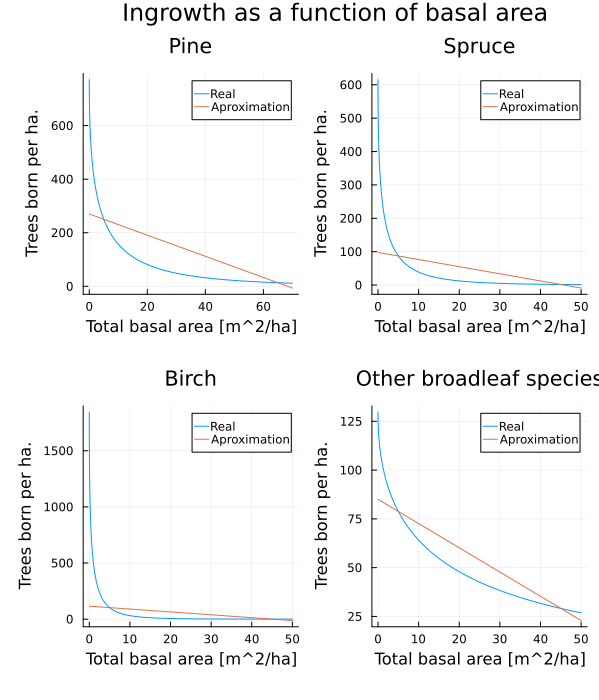

In [21]:
# Plots for all ingrowth functions, real and approximations.
p1 = plot(
    [BA -> ingrowth_BA_fn(BA, TS_test, coefs_ingrowth_pine), 
    BA -> ingrowth_BA_aprox["Pine"](BA, TS_test)], 
    0, 
    x2_pine + 5, 
    xlabel="Total basal area [m^2/ha]", 
    ylabel="Trees born per ha.",
    title="Pine", 
    label=["Real" "Aproximation"],
    left_margin=5mm, bottom_margin=5mm
    )
p2 = plot(
    [BA -> ingrowth_BA_fn(BA, TS_test, coefs_ingrowth_spruce), 
    BA -> ingrowth_BA_aprox["Spruce"](BA, TS_test)], 
    0, 
    x2_spruce + 5,
    xlabel="Total basal area [m^2/ha]", 
    ylabel="Trees born per ha.",
    title="Spruce", 
    label=["Real" "Aproximation"],
    bottom_margin=5mm
    )
p3 = plot(
    [BA -> ingrowth_BA_fn(BA, TS_test, coefs_ingrowth_birch), 
    BA -> ingrowth_BA_aprox["Birch"](BA, TS_test)], 
    0, 
    x2_birch + 5,
    xlabel="Total basal area [m^2/ha]", 
    ylabel="Trees born per ha.",
    title="Birch", 
    label=["Real" "Aproximation"],
    left_margin=5mm, bottom_margin=5mm
    )
p4 = plot(
    [BA -> ingrowth_BA_fn(BA, TS_test, coefs_ingrowth_broadleaf), 
    BA -> ingrowth_BA_aprox["Other broadleaf species"](BA, TS_test)], 
    0, 
    x2_broadleaf + 5,
    xlabel="Total basal area [m^2/ha]", 
    ylabel="Trees born per ha.",
    title="Other broadleaf species", 
    label=["Real" "Aproximation"],
    bottom_margin=5mm
    )
    
plot(
    p1, p2, p3, p4, 
    layout=(2,2), 
    size=(600,700), 
    plot_title="Ingrowth as a function of basal area"
    )

### **Simulations**

In [22]:
"""
     traj_BA(num_steps:Int64, initial_config:Vector{Float64}, 
     diam_matrix:Matrix{Float64}, surviv:Vector{Float64}, 
     ingrowth:Function)->Matrix{Float64}

Returns a simulation of the basal-area-dependent model according to the given arguments.

# Arguments
- `num_steps:Int64`: number of steps the simulation takes.
- `initial_config:Vector{Float64}`: initial configuration of the forest.
- `diam_matrix:Function`: function giving the transition matrix for the diameter classes
- `surviv:Function`: function returning survival rates for each diameter class.
- `ingrowth:Function`: ingrowth function.
"""
function traj_BA(num_steps, initial_config, diam_matrix, surviv, ingrowth, TS)
    X = Array{Float64}(undef, num_steps, n_classes)
    X[1,:] = initial_config
    for i in 2:num_steps
        Z = X[i-1,:]
        X[i,:] = diam_matrix(X[i-1,:] .* surviv(Z), TS) * X[i-1,:]
        X[i,1] += ingrowth(Z, TS)
    end
    return X
end;

In [23]:
"""
     simulate_and_plot_BA(species:String, num_steps:Int64, initial_config:Vector{Float64})

Simulates the base-dependent model for the chosen species both on the fixed-effects and 
mixed-effects cases, plotting both the evolution of the distribution on diameter classes 
and a pie chart with the final distribution.

# Arguments
- `species:String`: species modeled.
- `num_steps:Int64`: number of steps the simulation is ran, each one corresponding to five years.
- `initial_config:Vector{Float64}`: initial configuration of the diameter classes.  
"""
function simulate_and_plot_BA(species, num_steps, initial_config, TS)
    X_fixed = traj_BA(
        num_steps+1, 
        initial_config, 
        diam_BA[species], 
        surviv_BA[species, "fixed"], 
        ingrowth_BA[species],
        TS
        )
    X_mixed = traj_BA(
        num_steps+1, 
        initial_config, 
        diam_BA[species], 
        surviv_BA[species, "mixed"], 
        ingrowth_BA[species],
        TS
        )
    print("Initial size of the forest: ");println(sum(X_fixed[1,:]))
    print("Final size of the forest (fixed effects): ");println(sum(X_fixed[end,:]))
    print("Final size of the forest (mixed effects): ");println(sum(X_mixed[end,:]))
    pf1 = plot(
        0:5:num_steps*5, 
        X_fixed .+ 1, 
        yaxis=:log10, 
        label = legends, 
        legend = :outerright,
        title = "Evolution (fixed effects)", 
        left_margin=5mm,
        xlabel = "Time [years]", 
        ylabel = "Number of trees + 1"
        )
    pf2 = create_pie(
        X_fixed[end,:], 
        "fixed"
        )
    pm1 = plot(
        0:5:num_steps*5, 
        X_mixed .+ 1, 
        yaxis=:log10, 
        label = legends, 
        legend = :outerright,
        title = "Evolution (mixed effects)", 
        xlabel = "Time [years]", 
        ylabel = "Number of trees + 1"
        )
    pm2 = create_pie(
        X_mixed[end,:], 
        "mixed"
        )
    plot(
        pf1, pm1, pf2, pm2, 
        layout=(2,2), 
        size=(800,700), 
        plot_title=species*"'s models")
end;

In [24]:
# simulate_and_plot_BA("Pine", 100, X0, TS_test)

In [25]:
# simulate_and_plot_BA("Spruce", 100, X0, TS_test)

In [26]:
# simulate_and_plot_BA("Birch", 100, X0, TS_test)

In [27]:
# simulate_and_plot_BA("Other broadleaf species", 100, X0, TS_test)

# **Biomass: Jenkins's model**

In [28]:
# Coefficients used for biomass
coefs_biomass_pine = [-2.5356, 2.4349]
coefs_biomass_spruce = [-2.0773, 2.3323]
coefs_biomass_broadleaf = [-1.9123, 2.3651]

"""
     biomass_fn(d:Float64, coefs:Vector{Float64})-> Float64

Returns bm(d), based on the coefficients.

# Arguments
- `d::Float64`: diameter of the tree the function bm is being applied to.
- `coefs::Vector{Float64}`: coefficients of the function bm.
"""
biomass_fn = (d, coefs) -> exp(sum(coefs.*[1, log(d)]))

"""
     biomass_eval(coefs:Vector{Float64})-> Vector{Float64}

Returns the biomass values assigned to each class based on the coefficents.

# Arguments
- `coefs::Vector{Float64}`: coefficients of the function bm.
"""
biomass_eval = coefs -> [biomass_fn(d, coefs) for d in avg_diams]

# Biomass values for each species.
biomass = Dict()
biomass["Pine"] = biomass_eval(coefs_biomass_pine)
biomass["Spruce"] = biomass_eval(coefs_biomass_spruce)
biomass["Birch"] = biomass_eval(coefs_biomass_broadleaf)
biomass["Other broadleaf species"] = biomass_eval(coefs_biomass_broadleaf);

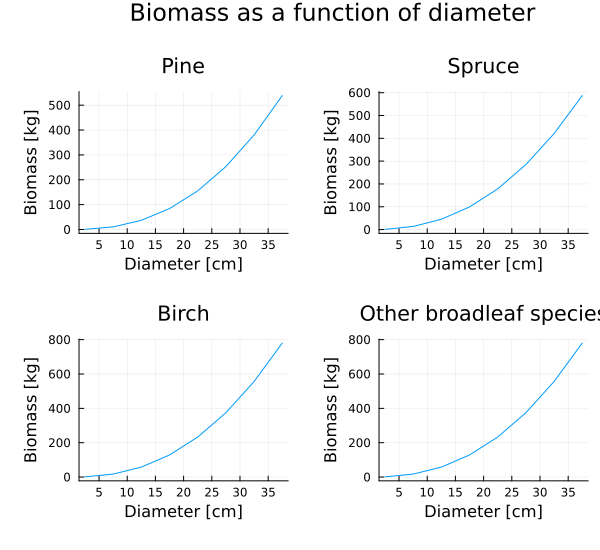

In [29]:
function plot_biomass(Species)
    p = plot(
    avg_diams,
    biomass[Species],
    legend=false,
    xaxis="Diameter [cm]", 
    yaxis="Biomass [kg]", 
    left_margin=5mm,
    bottom_margin=5mm, 
    title=Species
    )
    return p
end

p1 = plot_biomass("Pine")
p2 = plot_biomass("Spruce")
p3 = plot_biomass("Birch")
p4 = plot_biomass("Other broadleaf species")

plot(
    p1,p2,p3,p4,
    size=(600,550), 
    layout=(2,2), 
    plot_title="Biomass as a function of diameter",
    plot_titlevspan=0.1
    )

# **Optimization**

To finally implement the models on the $\texttt{SDDP.jl}$ library, first some initial pareters are set in place.

In [30]:
# initial condition
x0 = zeros(n_classes)
x0[1] = 600
x0[2] = 600

# discount factor
b = 0.975

0.975

We create three transition matrices, related to near, mid and long term average temperature differences relative to the 1850-1900 period according to the IPCC report. For the sake of clarity, this matrices have the followwing ranges:
- *Near term:* [1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9]
- *Mid-term:* [1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0]
- *Long-term:* [1.0, 1.4, 1.8, 2.2, 2.6, 3.0, 3.4, 3.8, 4.2, 4.6, 5.0, 5.4, 5.8]

In [31]:
near_term = [
    0.6 0.2 0.1 0.1 0.0 0.0 0.0 0.0
    0.1 0.5 0.2 0.1 0.1 0.0 0.0 0.0
    0.0 0.1 0.5 0.2 0.1 0.1 0.0 0.0
    0.0 0.0 0.1 0.5 0.2 0.1 0.1 0.0
    0.0 0.0 0.0 0.1 0.5 0.2 0.1 0.1   
    0.0 0.0 0.0 0.1 0.1 0.6 0.1 0.1
    0.0 0.0 0.0 0.0 0.1 0.1 0.6 0.2
    0.0 0.0 0.0 0.0 0.0 0.1 0.2 0.7
]

mid_term = [
    0.8 0.2 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    0.1 0.7 0.2 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    0.0 0.1 0.7 0.2 0.0 0.0 0.0 0.0 0.0 0.0
    0.0 0.0 0.1 0.7 0.2 0.0 0.0 0.0 0.0 0.0
    0.0 0.0 0.0 0.1 0.7 0.2 0.0 0.0 0.0 0.0   
    0.0 0.0 0.0 0.0 0.1 0.7 0.2 0.0 0.0 0.0
    0.0 0.0 0.0 0.0 0.0 0.1 0.7 0.2 0.0 0.0
    0.0 0.0 0.0 0.0 0.0 0.0 0.1 0.7 0.2 0.0
    0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.1 0.7 0.2
    0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.2 0.8     
]

long_term = [
    0.8 0.2 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    0.1 0.7 0.2 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    0.0 0.1 0.7 0.2 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    0.0 0.0 0.2 0.8 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    0.0 0.0 0.0 0.0 0.8 0.2 0.0 0.0 0.0 0.0 0.0 0.0 0.0   
    0.0 0.0 0.0 0.0 0.1 0.7 0.2 0.0 0.0 0.0 0.0 0.0 0.0
    0.0 0.0 0.0 0.0 0.0 0.1 0.7 0.2 0.0 0.0 0.0 0.0 0.0
    0.0 0.0 0.0 0.0 0.0 0.0 0.2 0.8 0.0 0.0 0.0 0.0 0.0
    0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.8 0.2 0.0 0.0 0.0
    0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.1 0.7 0.2 0.0 0.0 
    0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.1 0.7 0.2 0.0
    0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.1 0.7 0.2
    0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.2 0.8
];

In [32]:
near_to_mid = [
    0.7 0.2 0.1 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    0.1 0.6 0.2 0.1 0.0 0.0 0.0 0.0 0.0 0.0
    0.0 0.2 0.6 0.2 0.0 0.0 0.0 0.0 0.0 0.0
    0.0 0.0 0.2 0.6 0.2 0.0 0.0 0.0 0.0 0.0
    0.0 0.0 0.0 0.2 0.6 0.2 0.0 0.0 0.0 0.0   
    0.0 0.0 0.0 0.0 0.2 0.6 0.2 0.0 0.0 0.0
    0.0 0.0 0.0 0.0 0.0 0.2 0.6 0.1 0.1 0.0
    0.0 0.0 0.0 0.0 0.0 0.0 0.1 0.2 0.3 0.5    
]

mid_to_long = [
    0.2 0.3 0.3 0.2 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    0.0 0.2 0.3 0.3 0.2 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    0.0 0.0 0.2 0.3 0.3 0.2 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    0.0 0.0 0.0 0.2 0.3 0.3 0.2 0.0 0.0 0.0 0.0 0.0 0.0
    0.0 0.0 0.0 0.0 0.2 0.3 0.3 0.2 0.0 0.0 0.0 0.0 0.0   
    0.0 0.0 0.0 0.0 0.0 0.2 0.3 0.3 0.2 0.0 0.0 0.0 0.0
    0.0 0.0 0.0 0.0 0.0 0.0 0.2 0.3 0.3 0.2 0.0 0.0 0.0
    0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.2 0.3 0.3 0.2 0.0 0.0
    0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.1 0.3 0.3 0.3 0.0
    0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.2 0.3 0.5
];

In [64]:
function fire_prob(dt)
    return 0.002*exp(0.224(dt+14))
end

function eff_temp_sum(dt)
    return 1100 + (dt-1.4)*300
end

near_temps = [1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9]
mid_temps =  [1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0]
long_temps =  [1.0, 1.4, 1.8, 2.2, 2.6, 3.0, 3.4, 3.8, 4.2, 4.6, 5.0, 5.4, 5.8]

near_probs = fire_prob.(near_temps)
mid_probs = fire_prob.(mid_temps)
long_probs = fire_prob.(long_temps)

near_eff_temp_sums = eff_temp_sum.(near_temps)
mid_eff_temp_sums = eff_temp_sum.(mid_temps)
long_eff_temp_sums = eff_temp_sum.(long_temps);

fire_probs = Dict()
eff_temp_sums = Dict()
for i in 1:8, k in 1:5
    fire_probs[i+10*k] = near_probs[i]
    eff_temp_sums[i+10*k] = near_eff_temp_sums[i]
end
for i in 1:10, k in 1:7
    fire_probs[i+100*k] = mid_probs[i]
    eff_temp_sums[i+100*k] = mid_eff_temp_sums[i]
end
for i in 1:13, k in 1:5
    fire_probs[i+1000*k] = long_probs[i]
    eff_temp_sums[i+1000*k] = long_eff_temp_sums[i]
end;

In [34]:
initial_dist = [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]
graph = SDDP.Graph(0)

# near term nodes
for i in 1:8, k in 1:5
    SDDP.add_node(graph, i+10*k)
    if k==1
        SDDP.add_edge(graph, 0=>i+10*k, initial_dist[i])
    end
end
for i in 1:8, j in 1:8, k in 1:4
    SDDP.add_edge(graph, i+10k=>j+10(k+1), near_term[i,j]*b^5)
end


In [35]:

# mid-term nodes
for i in 1:10, k in 1:7
    SDDP.add_node(graph, i+100*k)
    if k==1
        for j in 1:8
            SDDP.add_edge(graph, j+10*5=>i+100*k, near_to_mid[j,i]*b^5)
        end
    end
end
for i in 1:10, j in 1:10, k in 1:6
    SDDP.add_edge(graph, i+100k=>j+100(k+1), mid_term[i,j]*b^5)
end
# long term nodes
for i in 1:13, k in 1:5
    SDDP.add_node(graph, i+1000*k)
    if k==1
        for j in 1:10
            SDDP.add_edge(graph, j+100*7=>i+1000*k, mid_to_long[j,i]*b^5)
        end
    end
end
for i in 1:13, j in 1:13, k in 1:4
    SDDP.add_edge(graph, i+1000k=>j+1000(k+1), long_term[i,j]*b^5)
end
for i in 1:13, j in 1:13
    SDDP.add_edge(graph, i+1000*5=>j+1000*5, long_term[i,j]*b^5)
end;

In [36]:
function scenario_graph(sc1, sc2, sc3)
    graph = SDDP.Graph(0)
    for k in 1:5
        SDDP.add_node(graph, sc1+10*k)
        if k==1
            SDDP.add_edge(graph, 0=>sc1+10*k, 1.0)
        else
            SDDP.add_edge(graph, sc1+10*(k-1)=>sc1+10*k, b^5)
        end
    end
    for k in 1:7
        SDDP.add_node(graph, sc2+100*k)
        if k==1
            SDDP.add_edge(graph, sc1+10*5=>sc2+100*k, b^5)
        else
            SDDP.add_edge(graph, sc2+100*(k-1)=>sc2+100*k, b^5)
        end
    end
    for k in 1:5
        SDDP.add_node(graph, sc3+1000*k)
        if k==1
            SDDP.add_edge(graph, sc2+100*7=>sc3+1000*k, b^5)
        else
            SDDP.add_edge(graph, sc3+1000*(k-1)=>sc3+1000*k, b^5)
        end
    end
    SDDP.add_edge(graph, sc3+1000*5=>sc3+1000*5, b^5)
    return graph
end;

graph1 = scenario_graph(4, 3, 2)
graph2 = scenario_graph(4, 4, 3)
graph3 = scenario_graph(4, 5, 5)
graph4 = scenario_graph(4, 6, 7)
graph5 = scenario_graph(5, 7, 9);

We create a function that defines a model depending on the ingrowth function.

In [37]:
x = 17.745*(1-exp(-0.085*sum(BAs[i] * x0[i] for i in 1:n_classes)))
for i in 1:50
    x = 17.745*(1-exp(-0.085*x))
end

In [65]:
"""
     dep_model(species:String, effect:String, ingrowth_fn:Function)->SDDP.PolicyGraph{Int64}

Returns a policy graph based on Pukkala's model under the assumption of a non-constant ingrowth function.

# Arguments
- `species::String`: species to be simulated.
- `effect::String`: model for the survival paremeters to be simulated.
- `ingrowth_fn::Function`: ingrowth function used in the model.
"""
function dep_model(species, effect, ingrowth_fn, UB, graph)
    model = SDDP.PolicyGraph(
        graph;
        sense = :Max,
        upper_bound = UB,
        # optimizer = Ipopt.Optimizer,
        optimizer = () -> Gurobi.Optimizer(GRB_ENV),
    ) do sp, t
        @variable(sp, x[s = 1:n_classes] >=0, SDDP.State, initial_value = x0[s]) # state variables, multidimensional.
        @variable(sp, x_survivors[s = 1:n_classes] >=0)
        @variable(sp, c[1:n_classes] >= 0) # control variables
        @variable(sp, BA >= 0) # basal area
        # @variable(sp, bm >= 0, SDDP.State, initial_value = 17.745*(1-exp(-0.085*sum(BAs[i] * x0[i] for i in 1:n_classes)))) # understory_biomass
        # @variable(sp, bm_control >= 0)
        @variable(sp, TV >= 0) # Timber volume
        @variable(sp, u >= 0) # slack variable to maximize, forced to be approx. TV^(1-α)/(1-α)   
        P = [fire_probs[t], 1-fire_probs[t]]
        Ω = [0.9, 1.0]
        diam_evol = diam[species](eff_temp_sums[t])
        survival = surviv[species, effect]
        ingrowth = ingrowth_fn[species]
        @constraints(sp, begin
                # bm.out == (bm.in - bm_control)* exp(0.085)
                balance_pre_fire[i = 1:n_classes], x_survivors[i] == sum(diam_evol[i,j]*((x[j].in - c[j])*survival[j]) for j in 1:n_classes)
                balance_non_samplings[i = 2:n_classes], x[i].out == x_survivors[i] # balance equations
                basal_area, sum(BAs[i] * x[i].out for i in 2:n_classes) == BA
                balance_samplings, x[1].out == x_survivors[1] + ingrowth(BA,eff_temp_sums[t])
                timber, sum(biomass[species][i] * c[i] for i in 1:n_classes) == TV # timber volume
                gain_approximation[i = 1:ny], u <= as[i]*TV + bs[i] #forces u to be approx. TV^(1-α)/(1-α)
            end)
        SDDP.parameterize(sp, Ω, P) do ω
            for i in 1:n_classes
                set_normalized_coefficient(balance_pre_fire[i], x_survivors[i], 1/ω)
            end            
        end
        @stageobjective(sp, u)
    end 
    return model
end

"""
     train(model:SDDP.PolicyGraph{Int64})->SDDP.PolicyGraph{Int64}

Returns a trained model.

# Arguments
- `model::SDDP.PolicyGraph{Int64}`: model to be trained.

"""
function train(model)
    SDDP.numerical_stability_report(model)
    SDDP.train(model, iteration_limit = n_train_iterations)
    return model
end;

Although it seems a bit unintuitive to have all these separete definitions, this will come in handy later.

In this implementation, the *forward passes* that select pivot points for the cuts are done by the non-linear model, while the *backward passes* that define the cuts are done by the linear model.

See the [Combining convex and non-convex models](https://sddp.dev/stable/tutorial/pglib_opf/#Combining-convex-and-non-convex-models) subsection on the $\texttt{SDDP.jl}$ documentation for a good explanation. 

In [66]:
"""
     modified_fwd_model(species:String, effect:String)->SDDP.PolicyGraph{Int64}

Returns a non-linear model for a species and effect, with cuts directly obtained at 
forward passes of said model, while the backward passes come from a linear version 
of the model for said species and effect.

# Arguments
- `species::String`: species to be simulated.
- `effect::String`: model for the survival paremeters to be simulated.
"""
function modified_fwd_model(species, effect, UB, graph)
    model_aprox = dep_model(species, effect, ingrowth_BA_aprox, UB, graph)
    model = dep_model(species, effect, ingrowth_BA, UB, graph)
    SDDP.train(
        model_aprox;
        forward_pass = SDDP.AlternativeForwardPass(model),
        post_iteration_callback = SDDP.AlternativePostIterationCallback(model),
        stopping_rules = [SDDP.BoundStalling(40, 1e-6), SDDP.IterationLimit(100)],
        # dashboard=true
    )
    return model
end;

### **Pine**

In [40]:
# model_0 = modified_fwd_model("Pine", "fixed", 6000, graph);

In [69]:
model_1 = modified_fwd_model("Pine", "fixed", 2000, graph1);

-------------------------------------------------------------------
         SDDP.jl (c) Oscar Dowson and contributors, 2017-25
-------------------------------------------------------------------
problem
  nodes           : 17
  state variables : 8
  scenarios       : Inf
  existing cuts   : false
options
  solver          : serial mode
  risk measure    : SDDP.Expectation()
  sampling scheme : SDDP.InSampleMonteCarlo
subproblem structure
  VariableRef                             : [36, 36]
  AffExpr in MOI.EqualTo{Float64}         : [18, 18]
  AffExpr in MOI.LessThan{Float64}        : [200, 200]
  VariableRef in MOI.GreaterThan{Float64} : [27, 27]
  VariableRef in MOI.LessThan{Float64}    : [1, 1]
numerical stability report
  matrix range     [4e-03, 5e+02]
  objective range  [1e+00, 1e+00]
  bounds range     [2e+03, 2e+03]
  rhs range        [5e-01, 3e+02]
-------------------------------------------------------------------
 iteration    simulation      bound        time (s)     solve

In [ ]:
model_2 = modified_fwd_model("Pine", "fixed", 2300, graph2);

-------------------------------------------------------------------
         SDDP.jl (c) Oscar Dowson and contributors, 2017-25
-------------------------------------------------------------------
problem
  nodes           : 17
  state variables : 8
  scenarios       : Inf
  existing cuts   : false
options
  solver          : serial mode
  risk measure    : SDDP.Expectation()
  sampling scheme : SDDP.InSampleMonteCarlo
subproblem structure
  VariableRef                             : [36, 36]
  AffExpr in MOI.EqualTo{Float64}         : [18, 18]
  AffExpr in MOI.LessThan{Float64}        : [200, 200]
  VariableRef in MOI.GreaterThan{Float64} : [27, 27]
  VariableRef in MOI.LessThan{Float64}    : [1, 1]
numerical stability report
  matrix range     [4e-03, 5e+02]
  objective range  [1e+00, 1e+00]
  bounds range     [1e+03, 1e+03]
  rhs range        [5e-01, 3e+02]
-------------------------------------------------------------------
 iteration    simulation      bound        time (s)     solve

In [ ]:
model_3 = modified_fwd_model("Pine", "fixed", 2300, graph3);

-------------------------------------------------------------------
         SDDP.jl (c) Oscar Dowson and contributors, 2017-25
-------------------------------------------------------------------
problem
  nodes           : 17
  state variables : 8
  scenarios       : Inf
  existing cuts   : false
options
  solver          : serial mode
  risk measure    : SDDP.Expectation()
  sampling scheme : SDDP.InSampleMonteCarlo
subproblem structure
  VariableRef                             : [36, 36]
  AffExpr in MOI.EqualTo{Float64}         : [18, 18]
  AffExpr in MOI.LessThan{Float64}        : [200, 200]
  VariableRef in MOI.GreaterThan{Float64} : [27, 27]
  VariableRef in MOI.LessThan{Float64}    : [1, 1]
numerical stability report
  matrix range     [4e-03, 5e+02]
  objective range  [1e+00, 1e+00]
  bounds range     [1e+03, 1e+03]
  rhs range        [5e-01, 5e+02]
-------------------------------------------------------------------
 iteration    simulation      bound        time (s)     solve

In [ ]:
model_4 = modified_fwd_model("Pine", "fixed", 2300, graph4);

-------------------------------------------------------------------
         SDDP.jl (c) Oscar Dowson and contributors, 2017-25
-------------------------------------------------------------------
problem
  nodes           : 17
  state variables : 8
  scenarios       : Inf
  existing cuts   : false
options
  solver          : serial mode
  risk measure    : SDDP.Expectation()
  sampling scheme : SDDP.InSampleMonteCarlo
subproblem structure
  VariableRef                             : [36, 36]
  AffExpr in MOI.EqualTo{Float64}         : [18, 18]
  AffExpr in MOI.LessThan{Float64}        : [200, 200]
  VariableRef in MOI.GreaterThan{Float64} : [27, 27]
  VariableRef in MOI.LessThan{Float64}    : [1, 1]
numerical stability report
  matrix range     [4e-03, 5e+02]
  objective range  [1e+00, 1e+00]
  bounds range     [1e+03, 1e+03]
  rhs range        [5e-01, 6e+02]
-------------------------------------------------------------------
 iteration    simulation      bound        time (s)     solve

In [73]:
model_5 = modified_fwd_model("Pine", "fixed", 2000, graph5);

-------------------------------------------------------------------
         SDDP.jl (c) Oscar Dowson and contributors, 2017-25
-------------------------------------------------------------------
problem
  nodes           : 17
  state variables : 8
  scenarios       : Inf
  existing cuts   : false
options
  solver          : serial mode
  risk measure    : SDDP.Expectation()
  sampling scheme : SDDP.InSampleMonteCarlo
subproblem structure
  VariableRef                             : [36, 36]
  AffExpr in MOI.EqualTo{Float64}         : [18, 18]
  AffExpr in MOI.LessThan{Float64}        : [200, 200]
  VariableRef in MOI.GreaterThan{Float64} : [27, 27]
  VariableRef in MOI.LessThan{Float64}    : [1, 1]
numerical stability report
  matrix range     [4e-03, 5e+02]
  objective range  [1e+00, 1e+00]
  bounds range     [2e+03, 2e+03]
  rhs range        [5e-01, 8e+02]
-------------------------------------------------------------------
 iteration    simulation      bound        time (s)     solve

In [74]:
colors = ["#4b99fb", "#d67548", "#52a24b", "#bd74d4", "#a68f15", "#45a8ae", "#e16694", "#bd8524"];

In [75]:
n_sim = 200

"""
     simulate_and_plot_trve(model:SDDP.PolicyGraph{Int64})->Tuple{Matrix{Float64}, Matrix{Float64}, Vector{Float64}}

Estimates both an upper bound and a confidence interval for the objective function through a 
series of simulations. Furthermore, it returns the evolution of the state vector, the control vector 
(chopped down trees) and the basal area of the longest simulation.

# Arguments
- `model::SDDP.PolicyGraph{Int64}`: model to be simulated.
"""

function simulate_and_plot_trve(model, species, scheme)
    simulations = SDDP.simulate(
        model, 
        n_sim,
        [:x, :c, :u, :BA],
        sampling_scheme = scheme;
    );
    # 
    # Y = reduce(hcat, [[simulations[1][t][:x][s].in for t in 1:70] for s in 1: n_classes])
    # C = reduce(hcat, [[simulations[1][t][:c][s] for t in 1:70] for s in 1: n_classes])
    # U = reduce(hcat, [simulations[1][t][:u] for t in 1:70])
    # BA = [simulations[1][t][:BA] for t in 1:70]
    objective_values = [
        sum(stage[:stage_objective] for stage in sim) for sim in simulations
    ]
    μ, ci = round.(SDDP.confidence_interval(objective_values, 1.96); digits = 2)
    u_bound = SDDP.calculate_bound(model)
    println("Confidence interval: ", μ, " ± ", ci)
    println("Upper bound: ", round(u_bound, digits = 2))
    # println("Initial size of the forest: ", sum(Y[1,:]))
    # println("Final size of the forest (fixed effects): ", sum(Y[end,:]))
    # println("Maximum basal area (fixed effects): ", maximum(BA))
    state_plots = []
    control_plots = []
    for i in 1:8
        s = SDDP.publication_plot(
            simulations;
            xformatter = x -> Int(x * 5),
            label="test",
            legend = :outerright, 
            title = "[$(5*(i-1)),$(5*i)] cm", 
            titlefontsize = 10, 
            xlabel = "Time [Years]", 
            ylabel = "Number of trees + 1",
            guidefontsize = 8,
            color = colors[i], 
            left_margin = -3mm,
            bottom_margin = 10mm
        ) do data
            return data[:x][i].in
        end
        c = SDDP.publication_plot(
            simulations;
            xformatter = x -> Int(x * 5),
            label="test",
            legend = :outerright, 
            title = "[$(5*(i-1)),$(5*i)] cm", 
            titlefontsize = 10, 
            xlabel = "Time [Years]", 
            ylabel = "Number of trees + 1",
            guidefontsize = 8,
            color = colors[i],
            left_margin = -3mm,
            bottom_margin = 10mm
        ) do data
            return data[:c][i]
        end
        push!(state_plots, s)
        push!(control_plots, c)
    end
    # pie_plot = create_pie(
        # Y[end,:], 
        # "fixed"
        # )
    area_plot = SDDP.publication_plot(
        simulations;
        xformatter = x -> Int(x * 5),
        label="Basal area",
        legend = :outerright, 
        title="Basal area", 
        xlabel="Time [Years]", 
        ylabel = "Total area [m^2/ha]"
    ) do data
        return data[:BA]
    end
    gain_plot = SDDP.publication_plot(
        simulations;
        xformatter = x -> Int(x * 5),
        label="Gain",
        legend = :outerright, 
        title="Gain function", 
        xlabel="Time [Years]", 
        ylabel = "money"
    ) do data
        return data[:u] + 1 
    end
    p1 = plot(state_plots..., layout=(1,8), plot_title="State variables")
    p2 = plot(control_plots..., layout=(1,8), plot_title="Control variables")
    p3 = plot(area_plot, gain_plot, layout=(1,3), size=(1450,450), )
    plot(p1, p2, p3, layout=(3,1), size=(1450,850))
end;

In [76]:
classic_scheme = SDDP.InSampleMonteCarlo(;
            max_depth=40,
            terminate_on_dummy_leaf = false,)

function scheme(model, depth, near_term, mid_term, long_term)
    scheme = SDDP.OutOfSampleMonteCarlo(model, max_depth=depth) do t
        if t == 0
            children = [SDDP.Noise(near_term, 1.0)]
            noise_terms = []
            return children
        else
            probability = [fire_probs[t], 1-fire_probs[t]]
            noise_terms = [SDDP.Noise(ω, p) for (ω, p) in zip(Ω, probability)]
            if t < 50
                children = [SDDP.Noise(t + 10, 1.0)]
            elseif t < 60
                children = [SDDP.Noise(mid_term, 1.0)]
            elseif t < 700
                children = [SDDP.Noise(t + 100, 1.0)]
            elseif t < 800
                children = [SDDP.Noise(long_term, 1.0)]
            elseif t < 5000
                children = [SDDP.Noise(t + 1000, 1.0)]
            else
                children = [SDDP.Noise(t, 0.95)]  
            end
            return children, noise_terms
        end
    end
    return scheme
end

scheme_1 = scheme(model_1, 40, 14, 103, 1002)
scheme_2 = scheme(model_1, 40, 14, 104, 1003)
scheme_3 = scheme(model_1, 40, 14, 105, 1005)
scheme_4 = scheme(model_1, 40, 14, 106, 1007)
scheme_5 = scheme(model_1, 40, 15, 107, 1009);

Confidence interval: 9652.58 ± 16.64
Upper bound: 1416.54


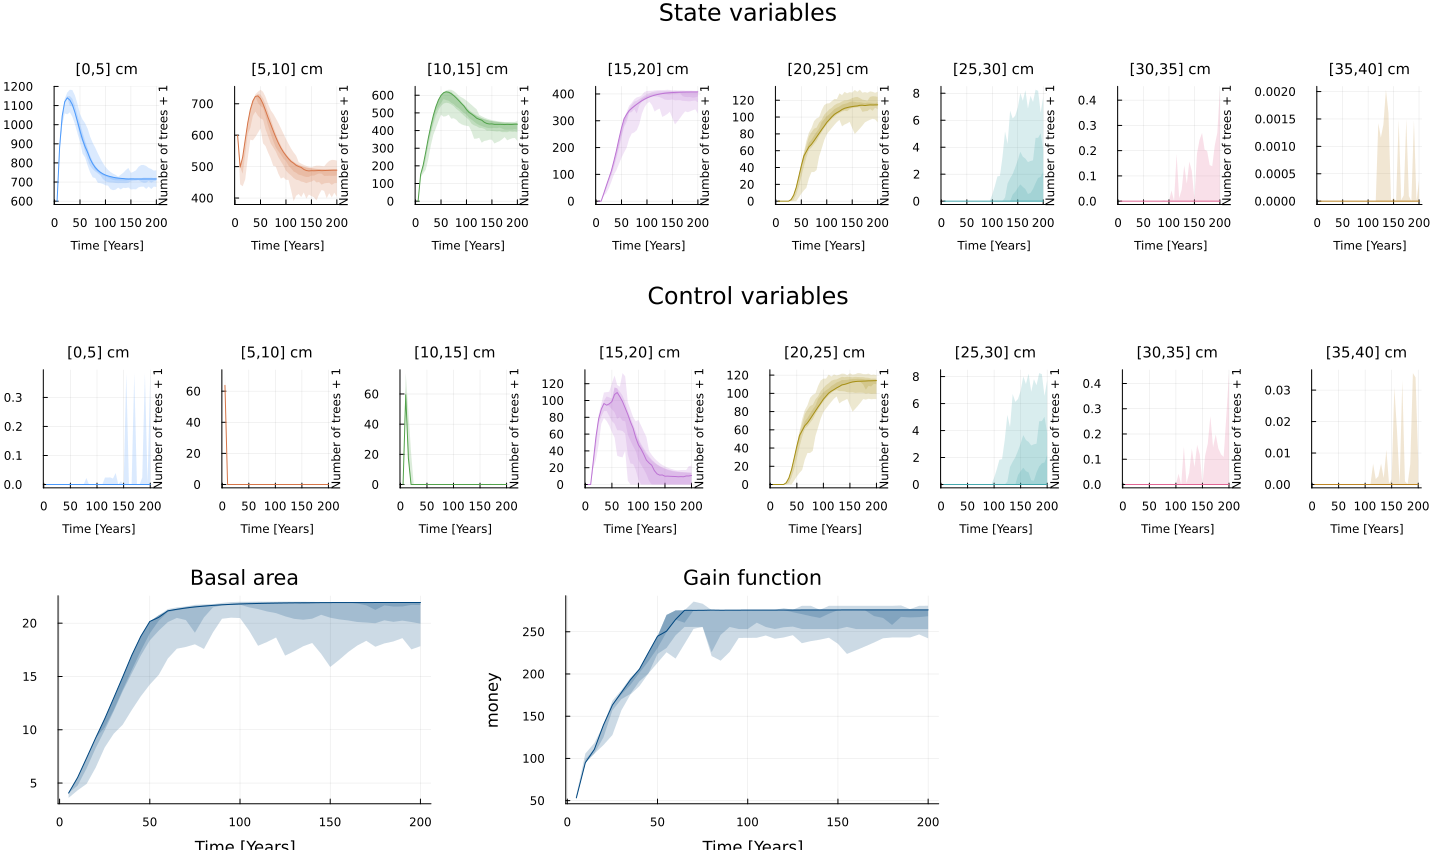

In [77]:
simulate_and_plot_trve(model_1, "Pine", classic_scheme)

Confidence interval: 6902.14 ± 2.84
Upper bound: 1266.15


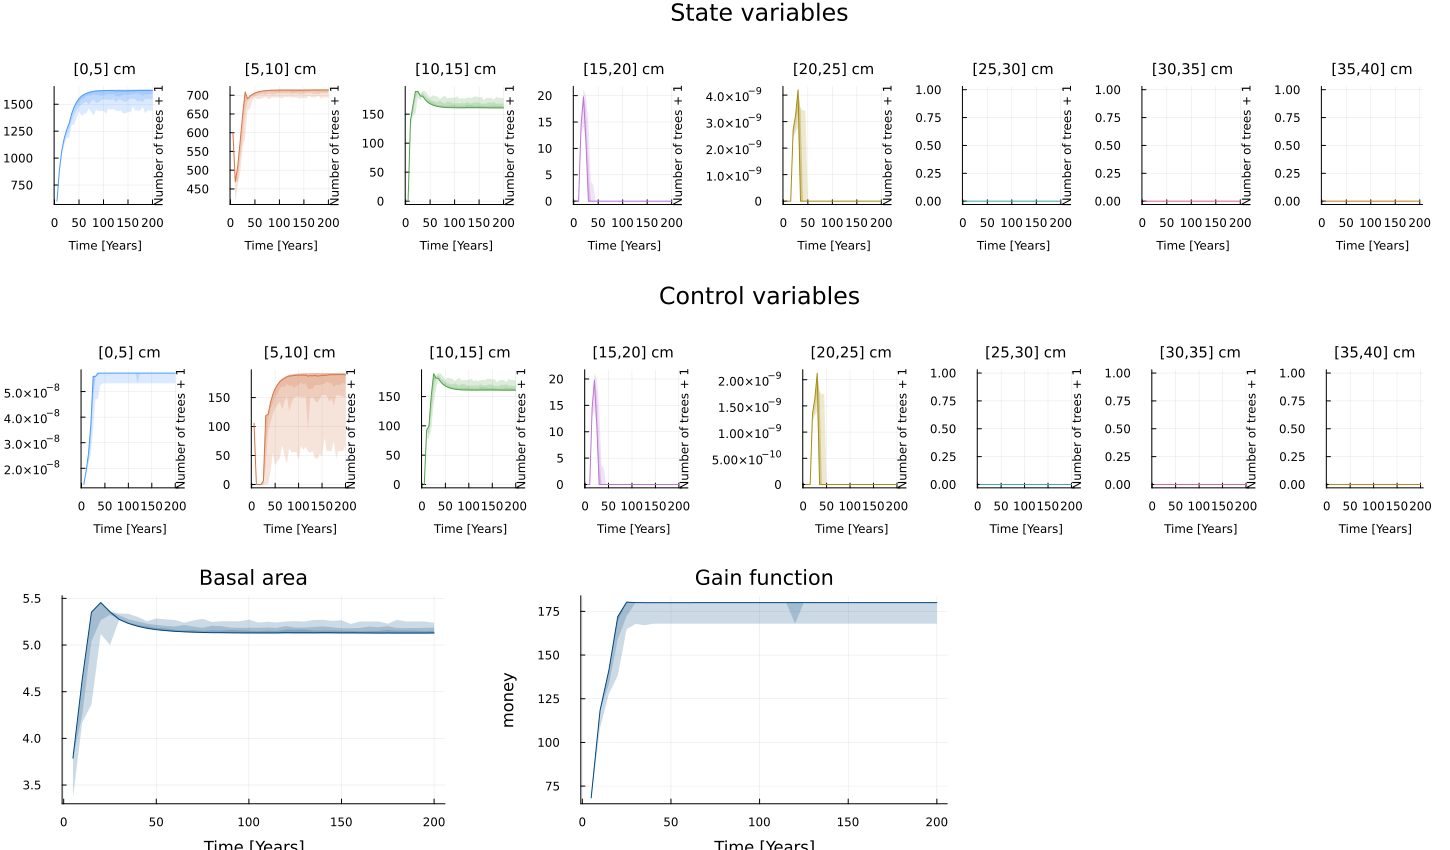

In [78]:
simulate_and_plot_trve(model_2, "Pine", classic_scheme)

Confidence interval: 6947.33 ± 2.74
Upper bound: 1269.56


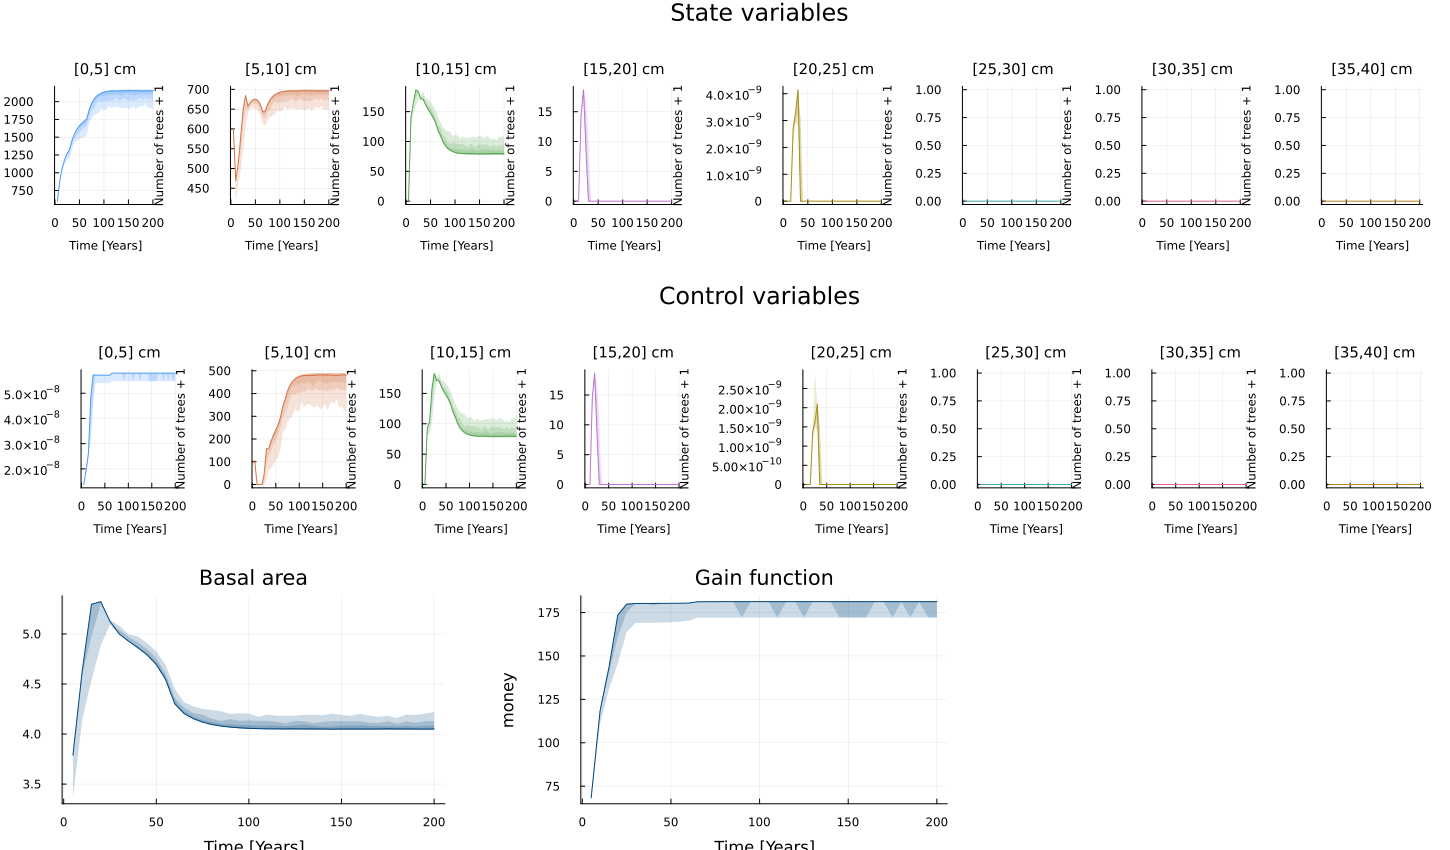

In [79]:
simulate_and_plot_trve(model_3, "Pine", classic_scheme)

Confidence interval: 6965.26 ± 2.12
Upper bound: 1272.33


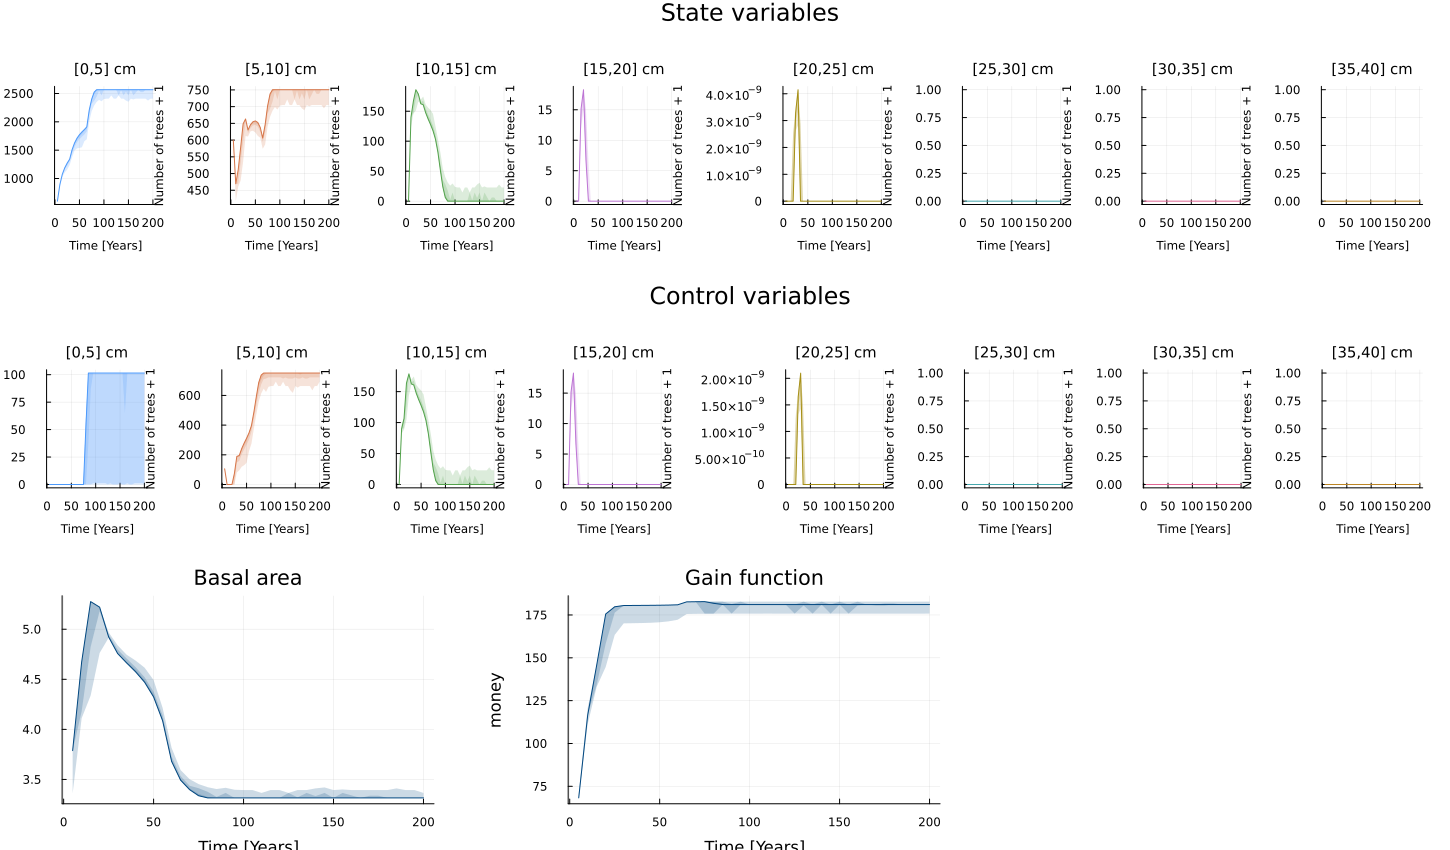

In [80]:
simulate_and_plot_trve(model_4, "Pine", classic_scheme)

Confidence interval: 9970.97 ± 5.94
Upper bound: 1549.1


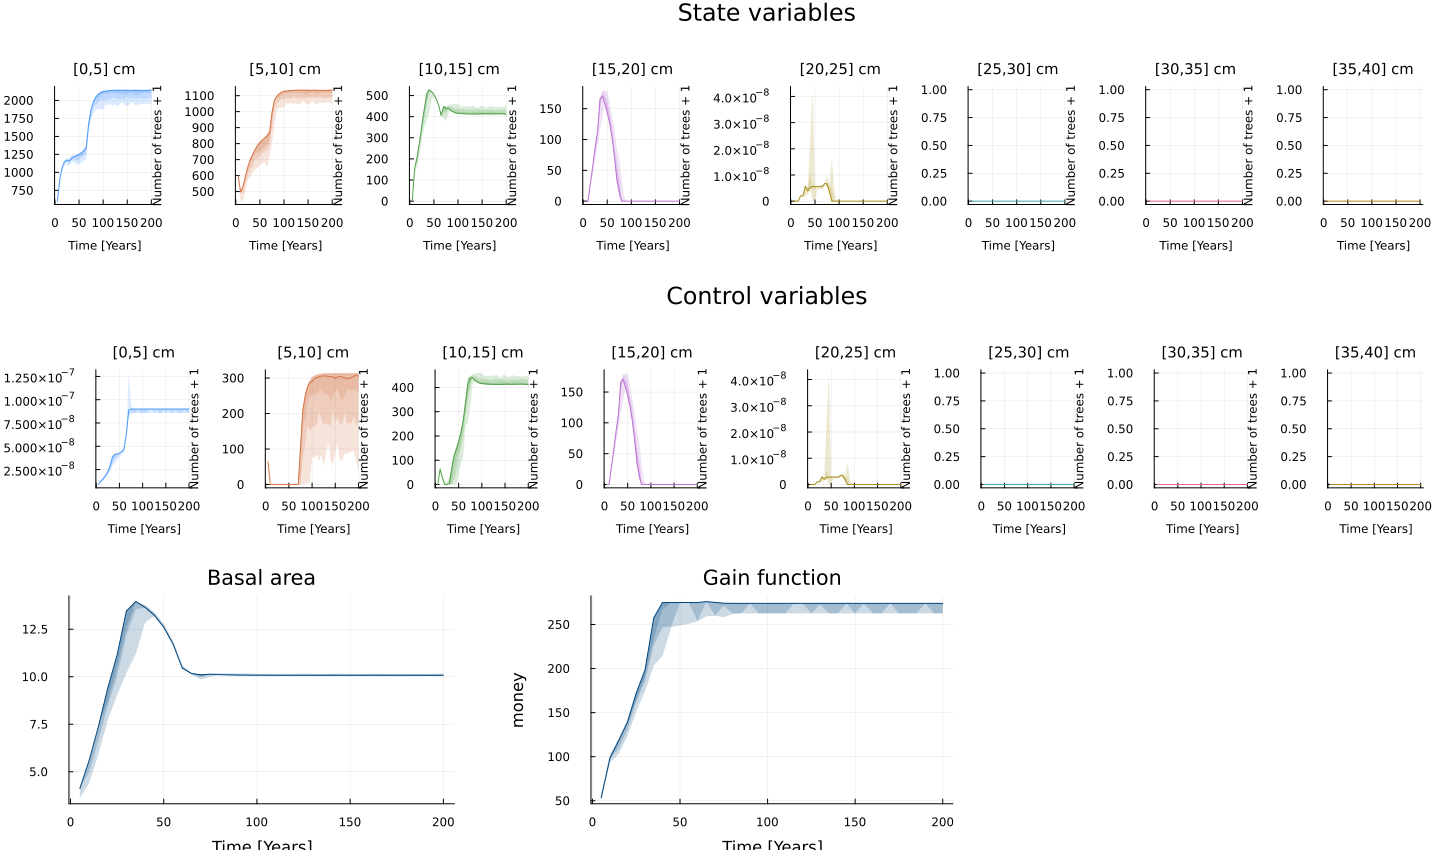

In [81]:
simulate_and_plot_trve(model_5, "Pine", classic_scheme)